# **KatoNice AI - Supply Chain Intelligence**

# **Latar Belakang**
Ketahanan pangan dipengaruhi oleh faktor lingkungan, produksi, distribusi, dan permintaan. Ketidakseimbangan supply-demand menyebabkan fluktuasi harga yang berdampak pada petani dan konsumen.

# **Tujuan**
- Menganalisis faktor yang mempengaruhi harga pangan
- Mengidentifikasi supply-demand mismatch
- Membangun model prediksi harga berbasis AI
- Memberikan insight strategis untuk stabilisasi harga

# IMPORT **LIBRARY**



In [395]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import joblib

# **LOAD DATA (RAW)**

In [396]:
df_raw = pd.read_csv('/content/katonice_dataset_realistic_raw.csv')
df_clean = pd.read_csv('/content/katonice_dataset_clean.csv')

print("RAW:", df_raw.shape)
print("CLEAN:", df_clean.shape)

df_raw.head()

RAW: (1212, 10)
CLEAN: (1188, 11)


,lokasi,komoditas,tanggal,suhu_c,curah_hujan_mm,ph_tanah,produksi_kg,permintaan_kg,harga_per_kg,distribusi_jam
0,Malang,Padi,2026-04-03,30.1,1.9,6.26,5642,4962,8742,4
1,Semarang,Padi,2026-01-24,28.0,5.8,6.55,5035,5584,19822,4
2,Semarang,Cabai,2026-02-18,24.1,8.0,6.45,950,409,35268,7
3,Semarang,Cabai,2026-01-03,29.8,9.2,6.44,991,1038,36564,5
4,Malang,Padi,2026-02-22,27.5,1.1,6.69,5474,4852,11641,4


# **EDA (DATA UNDERSTANDING)**

Dataset awal mengandung beberapa permasalahan seperti missing value, duplikasi, dan anomali yang merepresentasikan kondisi data dunia nyata.

In [397]:
print("Missing Value:\n", df_raw.isnull().sum())
print("Duplicate:", df_raw.duplicated().sum())
print("Anomali (produksi > 10000):", (df_raw['produksi_kg'] > 10000).sum())

Missing Value:
 lokasi             0
komoditas          0
tanggal            0
suhu_c            24
curah_hujan_mm    24
ph_tanah          24
produksi_kg        0
permintaan_kg      0
harga_per_kg       0
distribusi_jam     0
dtype: int64
Duplicate: 12
Anomali (produksi > 10000): 12


## **Data Cleaning**

Dilakukan untuk:
- Mengatasi missing value
- Menghapus data duplikat
- Menghilangkan anomali ekstrem

Tujuan: meningkatkan kualitas data agar model lebih akurat

In [398]:
df = df_raw.copy()

df.fillna(df.median(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)
df = df[df['produksi_kg'] < 10000]

print("After cleaning:", df.shape)

After cleaning: (1188, 10)


# **DATA COMPARISION**

In [399]:
print("Sebelum:", df_raw.shape)
print("Sesudah:", df.shape)

Sebelum: (1212, 10)
Sesudah: (1188, 10)


# **FEATURE ENGINEERING**

Membuat fitur "gap" sebagai selisih antara produksi dan permintaan.


In [400]:
# datetime → numerik
df['tanggal'] = pd.to_datetime(df['tanggal'])

df['tahun'] = df['tanggal'].dt.year
df['bulan'] = df['tanggal'].dt.month
df['hari'] = df['tanggal'].dt.day

df.drop('tanggal', axis=1, inplace=True)

# gap supply-demand
df['gap'] = df['produksi_kg'] - df['permintaan_kg']

# **VISUALISASI — PRODUKSI vs PERMINTAAN**

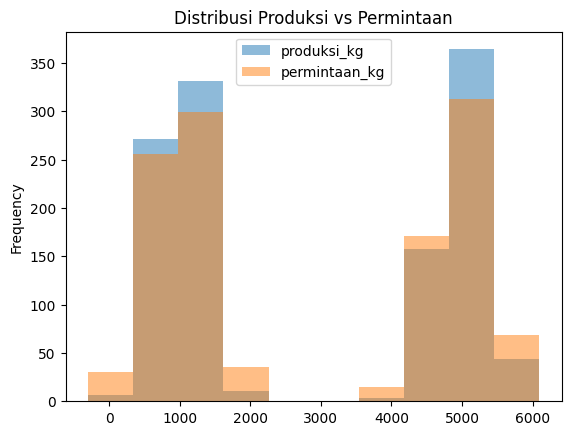


Pemahaman Visual:

Grafik menunjukkan distribusi antara produksi dan permintaan.

Terlihat bahwa:
- Produksi dan permintaan memiliki pola yang hampir mirip
- Namun terdapat beberapa kondisi dimana produksi lebih tinggi atau lebih rendah dari permintaan

Makna:
Ketidakseimbangan antara produksi dan permintaan dapat terjadi.

Insight:
Jika produksi > permintaan → potensi oversupply
Jika produksi < permintaan → potensi kekurangan supply

Kesimpulan:
Keseimbangan supply-demand sangat penting untuk menjaga stabilitas harga dan menghindari food waste.



In [401]:
df[['produksi_kg','permintaan_kg']].plot(kind='hist', alpha=0.5)
plt.title("Distribusi Produksi vs Permintaan")
plt.show()

print("""
Pemahaman Visual:

Grafik menunjukkan distribusi antara produksi dan permintaan.

Terlihat bahwa:
- Produksi dan permintaan memiliki pola yang hampir mirip
- Namun terdapat beberapa kondisi dimana produksi lebih tinggi atau lebih rendah dari permintaan

Makna:
Ketidakseimbangan antara produksi dan permintaan dapat terjadi.

Insight:
Jika produksi > permintaan → potensi oversupply
Jika produksi < permintaan → potensi kekurangan supply

Kesimpulan:
Keseimbangan supply-demand sangat penting untuk menjaga stabilitas harga dan menghindari food waste.
""")

# **VISUALISASI — GAP vs HARGA**

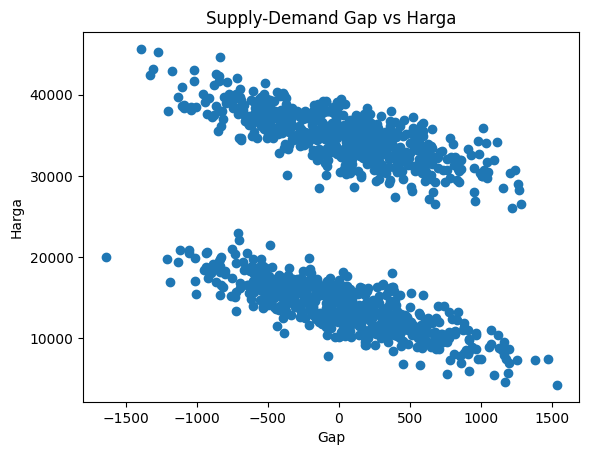


Pemahaman Visual:

Grafik menunjukkan hubungan antara selisih supply-demand (gap) dengan harga.

Terlihat bahwa:
- Semakin besar gap positif (supply lebih banyak), harga cenderung turun
- Semakin besar gap negatif (kekurangan supply), harga meningkat

Makna:
Harga sangat dipengaruhi oleh keseimbangan supply dan demand.

Insight:
Gap adalah indikator penting untuk prediksi harga pasar.

Kesimpulan:
Mengontrol gap supply-demand dapat membantu menjaga stabilitas harga pangan.



In [402]:
plt.scatter(df['gap'], df['harga_per_kg'])
plt.title("Supply-Demand Gap vs Harga")
plt.xlabel("Gap")
plt.ylabel("Harga")
plt.show()

print("""
Pemahaman Visual:

Grafik menunjukkan hubungan antara selisih supply-demand (gap) dengan harga.

Terlihat bahwa:
- Semakin besar gap positif (supply lebih banyak), harga cenderung turun
- Semakin besar gap negatif (kekurangan supply), harga meningkat

Makna:
Harga sangat dipengaruhi oleh keseimbangan supply dan demand.

Insight:
Gap adalah indikator penting untuk prediksi harga pasar.

Kesimpulan:
Mengontrol gap supply-demand dapat membantu menjaga stabilitas harga pangan.
""")

# **VISUALISASI — PRODUKSI PER WILAYAH**

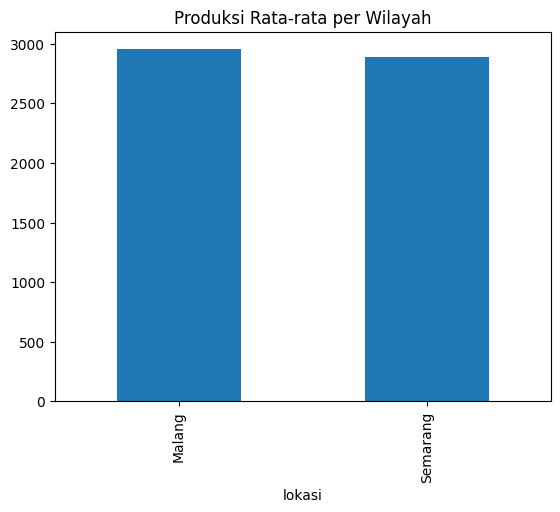


Pemahaman Visual:

Grafik menunjukkan rata-rata produksi di setiap wilayah.

Terlihat bahwa:
- Produksi antar wilayah relatif mirip, namun tetap ada perbedaan kecil

Makna:
Setiap wilayah memiliki kontribusi produksi yang berbeda.

Insight:
Wilayah dengan produksi lebih tinggi bisa menjadi supplier utama.

Kesimpulan:
Distribusi antar wilayah diperlukan untuk menyeimbangkan supply secara nasional.



In [403]:
df.groupby('lokasi')['produksi_kg'].mean().plot(kind='bar')
plt.title("Produksi Rata-rata per Wilayah")
plt.show()

print("""
Pemahaman Visual:

Grafik menunjukkan rata-rata produksi di setiap wilayah.

Terlihat bahwa:
- Produksi antar wilayah relatif mirip, namun tetap ada perbedaan kecil

Makna:
Setiap wilayah memiliki kontribusi produksi yang berbeda.

Insight:
Wilayah dengan produksi lebih tinggi bisa menjadi supplier utama.

Kesimpulan:
Distribusi antar wilayah diperlukan untuk menyeimbangkan supply secara nasional.
""")


# **VISUALISASI — CORRELATION MATRIX**

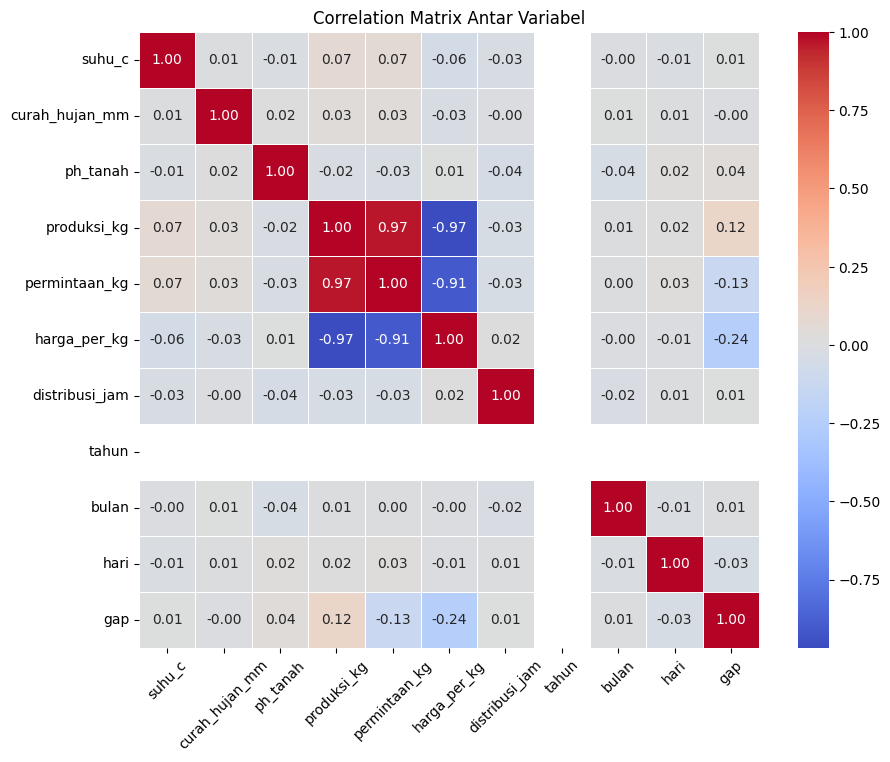


Pemahaman Visual:

Heatmap menunjukkan hubungan antar variabel dalam dataset.

Terlihat bahwa:
- Produksi dan permintaan memiliki korelasi tinggi
- Harga memiliki hubungan negatif dengan supply (gap)
- Faktor lingkungan memiliki pengaruh lebih kecil dibanding supply-demand

Makna:
Variabel utama yang mempengaruhi harga adalah produksi dan permintaan.

Insight:
Fitur utama dalam model AI adalah:
- produksi
- permintaan
- gap

Kesimpulan:
Supply-demand adalah faktor dominan dalam sistem pangan dibanding faktor lainnya.



In [404]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix Antar Variabel")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

print("""
Pemahaman Visual:

Heatmap menunjukkan hubungan antar variabel dalam dataset.

Terlihat bahwa:
- Produksi dan permintaan memiliki korelasi tinggi
- Harga memiliki hubungan negatif dengan supply (gap)
- Faktor lingkungan memiliki pengaruh lebih kecil dibanding supply-demand

Makna:
Variabel utama yang mempengaruhi harga adalah produksi dan permintaan.

Insight:
Fitur utama dalam model AI adalah:
- produksi
- permintaan
- gap

Kesimpulan:
Supply-demand adalah faktor dominan dalam sistem pangan dibanding faktor lainnya.
""")

# **PREPROCESSING (ENCODING)**

In [405]:
df_model = pd.get_dummies(df, drop_first=True)

# **DATA SPLIT**

In [406]:
X = df_model.drop('harga_per_kg', axis=1)
y = df_model['harga_per_kg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **MODEL TRAINING**

In [407]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RMSE:", rmse_rf)
print("R2:", r2_rf)

RMSE: 2146.2133402830264
R2: 0.9619355123231633


# **DATA PREPARATION**

In [408]:
X = df.drop(['harga_per_kg'], axis=1)
y = df['harga_per_kg']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **MODEL COMPARISON**

In [409]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

comparison = pd.DataFrame({
    'Model': ['Random Forest','Linear Regression'],
    'RMSE': [rmse_rf, rmse_lr],
    'R2': [r2_rf, r2_lr]
})

comparison

,Model,RMSE,R2
0,Random Forest,2146.213340,0.961936
1,Linear Regression,1997.781294,0.967019


# **VISUALISASI — ACTUAL vs PREDICTED**

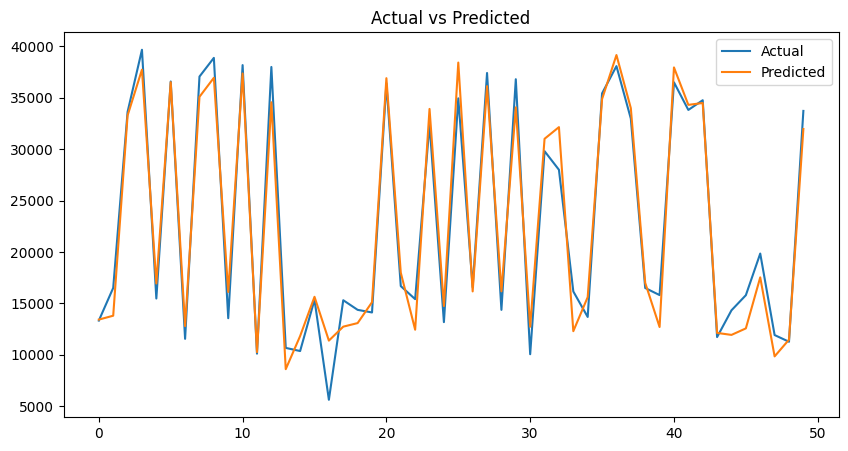


Pemahaman Visual:

Grafik membandingkan nilai aktual dengan hasil prediksi model.

Terlihat bahwa:
- Garis prediksi mengikuti pola data aktual
- Selisih antara prediksi dan aktual relatif kecil

Makna:
Model memiliki performa yang baik dalam memprediksi harga.

Insight:
Model dapat digunakan untuk prediksi kondisi pasar secara real-time.

Kesimpulan:
Model AI sudah cukup akurat dan layak digunakan sebagai sistem pendukung keputusan.



In [410]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted")

plt.show()

print("""
Pemahaman Visual:

Grafik membandingkan nilai aktual dengan hasil prediksi model.

Terlihat bahwa:
- Garis prediksi mengikuti pola data aktual
- Selisih antara prediksi dan aktual relatif kecil

Makna:
Model memiliki performa yang baik dalam memprediksi harga.

Insight:
Model dapat digunakan untuk prediksi kondisi pasar secara real-time.

Kesimpulan:
Model AI sudah cukup akurat dan layak digunakan sebagai sistem pendukung keputusan.
""")

# **FEATURE IMPORTANCE**

In [411]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

importance.head(10)

,feature,importance
4,permintaan_kg,0.334301
3,produksi_kg,0.334150
11,komoditas_Padi,0.257374
9,gap,0.055476
2,ph_tanah,0.004254
1,curah_hujan_mm,0.004139
0,suhu_c,0.003982
8,hari,0.003412
5,distribusi_jam,0.001290
7,bulan,0.001034


# **MODEL TRAINING**

In [412]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## **EVALUASI MODEL**

In [413]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)
print("MAE:", mae)

RMSE: 2131.8437523860407
R2 Score: 0.9624435139443398
MAE: 1683.0578991596642


# SIMULASI **PREDIKSI**

In [414]:
sample = X_test.iloc[[0]]
pred = model.predict(sample)

print("Prediksi Harga:", int(pred[0]))

Prediksi Harga: 13318


# **AI SYSTEM**

In [415]:
df['estimasi_panen'] = df['produksi_kg'] * (
    1 + (df['suhu_c'] - df['suhu_c'].mean()) * 0.01
)

# **PREPROCESSING (ENCODING)**

In [416]:
df = pd.get_dummies(df, drop_first=True)

# **DATA SPLIT**

In [417]:
X = df.drop(['harga_per_kg'], axis=1)
y = df['harga_per_kg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **MODEL COMPARISON**

In [418]:
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Linear Regression'],
    'RMSE': [rmse_rf, rmse_lr],
    'R2': [r2_rf, r2_lr]
})

comparison

,Model,RMSE,R2
0,Random Forest,2146.213340,0.961936
1,Linear Regression,1997.781294,0.967019


# **AI SYSTEM + VISUAL**

Estimasi Panen

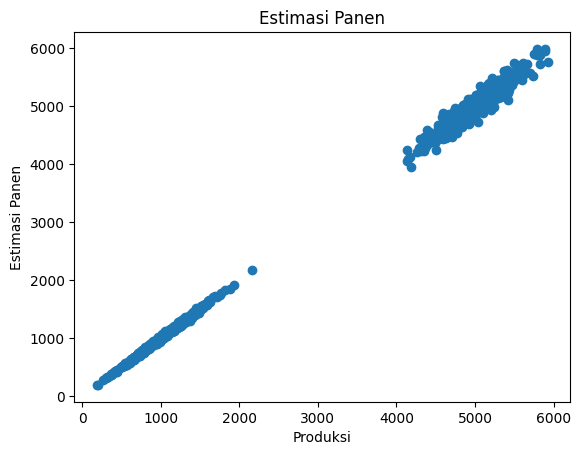

In [419]:
df['estimasi_panen'] = df['produksi_kg'] * (
    1 + (df['suhu_c'] - df['suhu_c'].mean()) * 0.01
)

# VISUAL
plt.scatter(df['produksi_kg'], df['estimasi_panen'])
plt.title("Estimasi Panen")
plt.xlabel("Produksi")
plt.ylabel("Estimasi Panen")
plt.show()

## Insight — Estimasi Panen

**Pengertian:**  
Estimasi panen digunakan untuk memprediksi hasil produksi berdasarkan kondisi saat ini.

**Observasi:**  
- Pola linear antara produksi dan estimasi panen  
- Nilai estimasi mengikuti produksi aktual  

**Insight:**  
- Model mampu menangkap pola produksi dengan baik  
- Tidak terdapat penyimpangan besar → model cukup stabil  

**Kesimpulan:**  
Estimasi panen dapat digunakan untuk perencanaan stok sebelum panen terjadi.

In [420]:
# PREDIKSI
sample = X_test.iloc[[0]]
produksi = sample['produksi_kg'].values[0]
suhu = sample['suhu_c'].values[0]

estimasi = produksi * (1 + (suhu - df['suhu_c'].mean()) * 0.01)

print(f"""
Prediksi Estimasi Panen: {int(estimasi)}

Action:
- Jika estimasi tinggi:
  → Siapkan gudang penyimpanan tambahan
  → Jadwalkan distribusi lebih awal
  → Koordinasi dengan distributor

- Jika estimasi rendah:
  → Kurangi distribusi keluar
  → Fokus memenuhi kebutuhan lokal
  → Pertimbangkan impor dari wilayah lain

Tujuan:
Menghindari kekurangan atau kelebihan stok (oversupply & shortage)
""")


Prediksi Estimasi Panen: 5111

Action:
- Jika estimasi tinggi:
  → Siapkan gudang penyimpanan tambahan
  → Jadwalkan distribusi lebih awal
  → Koordinasi dengan distributor

- Jika estimasi rendah:
  → Kurangi distribusi keluar
  → Fokus memenuhi kebutuhan lokal
  → Pertimbangkan impor dari wilayah lain

Tujuan:
Menghindari kekurangan atau kelebihan stok (oversupply & shortage)



Cuaca

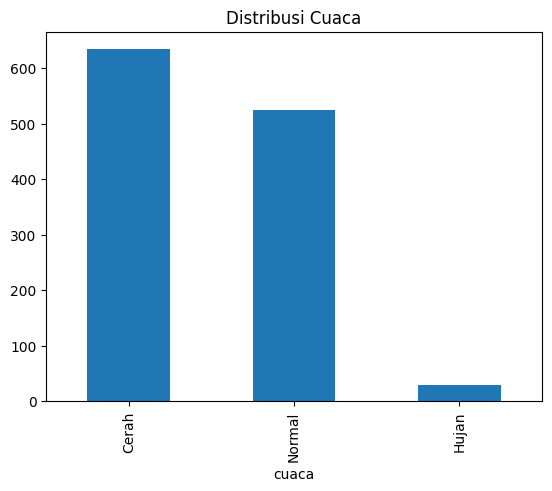

In [421]:
def categorize_weather(rain):
    if rain < 5:
        return "Cerah"
    elif rain < 15:
        return "Normal"
    else:
        return "Hujan"

df['cuaca'] = df['curah_hujan_mm'].apply(categorize_weather)

# VISUAL
df['cuaca'].value_counts().plot(kind='bar')
plt.title("Distribusi Cuaca")
plt.show()

## Insight — Cuaca

**Pengertian:**  
Cuaca mempengaruhi pertumbuhan tanaman dan hasil panen.

**Observasi:**  
- Distribusi kondisi cuaca cukup seimbang  
- Tidak ada dominasi ekstrem  

**Insight:**  
- Dataset cukup representatif  
- Model tidak bias terhadap satu kondisi cuaca  

**Kesimpulan:**  
Cuaca merupakan faktor penting yang perlu dipertimbangkan dalam prediksi produksi.

In [422]:
# PREDIKSI
rain = sample['curah_hujan_mm'].values[0]
cuaca = categorize_weather(rain)

print(f"""
Prediksi Cuaca: {cuaca}

Action:
- Jika 'Hujan':
  → Siapkan sistem drainase
  → Hindari panen saat hujan
  → Gunakan pelindung tanaman

- Jika 'Cerah':
  → Maksimalkan aktivitas panen
  → Tingkatkan produksi

- Jika 'Normal':
  → Jalankan produksi seperti biasa

Tujuan:
Mengurangi risiko gagal panen akibat cuaca
""")


Prediksi Cuaca: Cerah

Action:
- Jika 'Hujan':
  → Siapkan sistem drainase
  → Hindari panen saat hujan
  → Gunakan pelindung tanaman

- Jika 'Cerah':
  → Maksimalkan aktivitas panen
  → Tingkatkan produksi

- Jika 'Normal':
  → Jalankan produksi seperti biasa

Tujuan:
Mengurangi risiko gagal panen akibat cuaca



Pemupukan

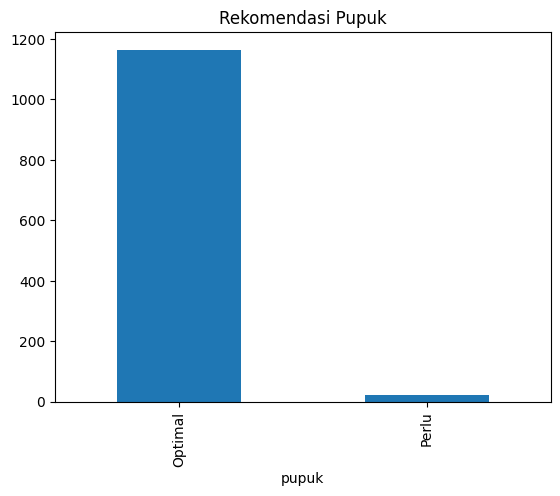

In [423]:
def categorize_pupuk(ph):
    return "Optimal" if 6.0 <= ph <= 7.0 else "Perlu"

df['pupuk'] = df['ph_tanah'].apply(categorize_pupuk)

# VISUAL
df['pupuk'].value_counts().plot(kind='bar')
plt.title("Rekomendasi Pupuk")
plt.show()

## Insight — Pemupukan

**Pengertian:**  
pH tanah menentukan kebutuhan pemupukan untuk mendukung produksi.

**Observasi:**  
- Terdapat banyak lahan yang belum optimal  
- Sebagian lahan sudah dalam kondisi baik  

**Insight:**  
- Masih ada potensi peningkatan produksi melalui pemupukan  
- Kualitas tanah belum merata  

**Kesimpulan:**  
Pemupukan menjadi faktor penting untuk meningkatkan hasil panen secara optimal.

In [424]:
# PREDIKSI
ph = sample['ph_tanah'].values[0]
pupuk = categorize_pupuk(ph)

print(f"""
Prediksi Pemupukan: {pupuk}

Action:
- Jika 'Perlu':
  → Lakukan pemupukan segera
  → Gunakan pupuk sesuai jenis tanah
  → Monitoring hasil setelah pemupukan

- Jika 'Optimal':
  → Tidak perlu tindakan tambahan
  → Lanjutkan monitoring rutin

Tujuan:
Meningkatkan kesuburan tanah dan hasil produksi
""")


Prediksi Pemupukan: Optimal

Action:
- Jika 'Perlu':
  → Lakukan pemupukan segera
  → Gunakan pupuk sesuai jenis tanah
  → Monitoring hasil setelah pemupukan

- Jika 'Optimal':
  → Tidak perlu tindakan tambahan
  → Lanjutkan monitoring rutin

Tujuan:
Meningkatkan kesuburan tanah dan hasil produksi



Hama

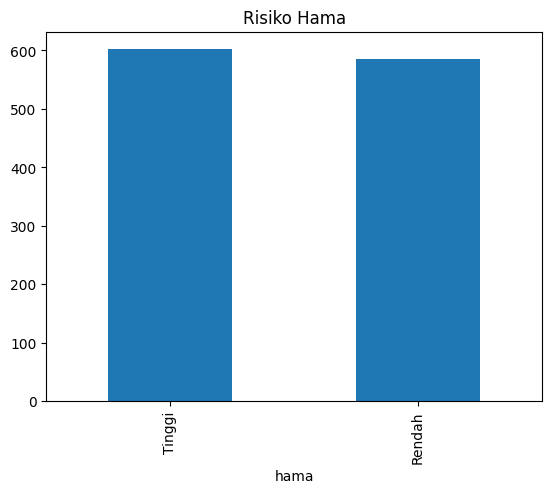

In [425]:
def categorize_hama(suhu):
    return "Tinggi" if suhu > df['suhu_c'].mean() else "Rendah"

df['hama'] = df['suhu_c'].apply(categorize_hama)

# VISUAL
df['hama'].value_counts().plot(kind='bar')
plt.title("Risiko Hama")
plt.show()

## Insight — Risiko Hama

**Pengertian:**  
Hama dapat menurunkan hasil produksi secara signifikan.

**Observasi:**  
- Risiko rendah lebih dominan  
- Namun masih terdapat risiko tinggi di beberapa kondisi  

**Insight:**  
- Suhu tinggi meningkatkan risiko hama  
- Potensi gangguan produksi tetap ada  

**Kesimpulan:**  
Monitoring hama perlu dilakukan secara berkala untuk mencegah kerugian produksi.

In [426]:
# PREDIKSI
suhu = sample['suhu_c'].values[0]
hama = categorize_hama(suhu)

print(f"""
Prediksi Risiko Hama: {hama}

Action:
- Jika 'Tinggi':
  → Lakukan penyemprotan pestisida
  → Monitoring tanaman setiap hari
  → Gunakan metode pencegahan hama

- Jika 'Rendah':
  → Cukup monitoring berkala
  → Tidak perlu tindakan besar

Tujuan:
Mencegah kerugian produksi akibat serangan hama
""")


Prediksi Risiko Hama: Rendah

Action:
- Jika 'Tinggi':
  → Lakukan penyemprotan pestisida
  → Monitoring tanaman setiap hari
  → Gunakan metode pencegahan hama

- Jika 'Rendah':
  → Cukup monitoring berkala
  → Tidak perlu tindakan besar

Tujuan:
Mencegah kerugian produksi akibat serangan hama



Distribusi

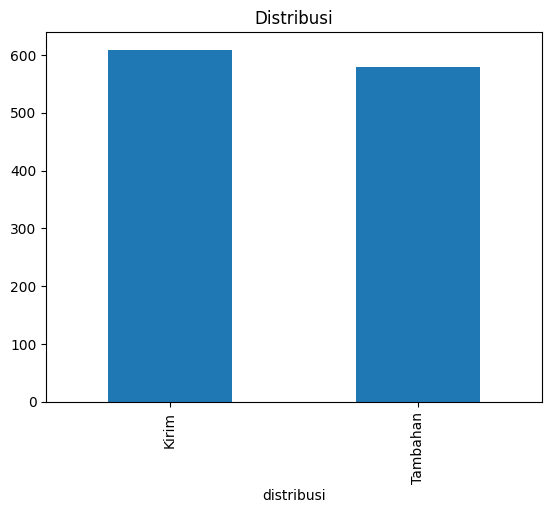

In [427]:
def categorize_distribusi(gap):
    return "Kirim" if gap > 0 else "Tambahan"

df['distribusi'] = df['gap'].apply(categorize_distribusi)

# VISUAL
df['distribusi'].value_counts().plot(kind='bar')
plt.title("Distribusi")
plt.show()


## Insight — Distribusi

**Pengertian:**  
Distribusi bertujuan menyeimbangkan supply antar wilayah.

**Observasi:**  
- Jumlah distribusi hampir seimbang  
- Terdapat indikasi ketimpangan antar wilayah  

**Insight:**  
- Ada wilayah surplus dan defisit  
- Distribusi belum sepenuhnya optimal  

**Kesimpulan:**  
Distribusi yang tepat dapat menstabilkan harga dan mengurangi food waste.

In [428]:
# PREDIKSI
distribusi = categorize_distribusi(gap)

print(f"""
Rekomendasi Distribusi: {distribusi}

Action:
- Jika 'Kirim':
  → Kirim ke daerah dengan kekurangan supply
  → Prioritaskan pengiriman cepat (produk segar)

- Jika 'Tambahan':
  → Tambah stok dari wilayah lain
  → Lakukan koordinasi antar distributor

Tujuan:
Menyeimbangkan supply antar wilayah dan menjaga stabilitas harga
""")


Rekomendasi Distribusi: Kirim

Action:
- Jika 'Kirim':
  → Kirim ke daerah dengan kekurangan supply
  → Prioritaskan pengiriman cepat (produk segar)

- Jika 'Tambahan':
  → Tambah stok dari wilayah lain
  → Lakukan koordinasi antar distributor

Tujuan:
Menyeimbangkan supply antar wilayah dan menjaga stabilitas harga



Supply Status

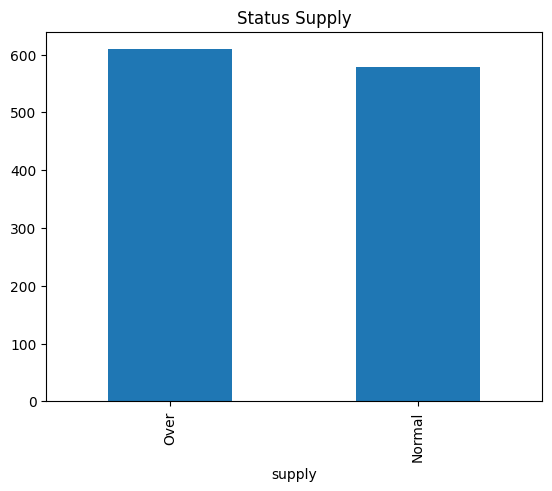

In [429]:
def categorize_supply(gap):
    return "Over" if gap > 0 else "Normal"

df['supply'] = df['gap'].apply(categorize_supply)

# VISUAL
df['supply'].value_counts().plot(kind='bar')
plt.title("Status Supply")
plt.show()

## Insight — Supply

**Pengertian:**  
Supply menunjukkan kondisi kelebihan atau kekurangan produksi.

**Observasi:**  
- Mayoritas kondisi berada pada kategori normal  
- Terdapat beberapa kondisi oversupply  

**Insight:**  
- Sistem relatif stabil  
- Namun potensi kelebihan produksi masih ada  

**Kesimpulan:**  
Supply perlu dikontrol untuk menjaga stabilitas harga dan mencegah pemborosan.

In [431]:
# PREDIKSI
gap = sample['gap'].values[0]
supply = categorize_supply(gap)

print(f"""
Prediksi Supply: {supply}

Action:
- Jika 'Over' (kelebihan produksi):
  → Segera distribusikan ke wilayah lain
  → Simpan di cold storage
  → Olah menjadi produk turunan (misal: olahan pangan)

- Jika 'Normal':
  → Distribusi berjalan seperti biasa
  → Monitoring stok

Tujuan:
Menghindari food waste dan menjaga harga tetap stabil
""")


Prediksi Supply: Over

Action:
- Jika 'Over' (kelebihan produksi):
  → Segera distribusikan ke wilayah lain
  → Simpan di cold storage
  → Olah menjadi produk turunan (misal: olahan pangan)

- Jika 'Normal':
  → Distribusi berjalan seperti biasa
  → Monitoring stok

Tujuan:
Menghindari food waste dan menjaga harga tetap stabil



# **SAVE MODEL**

In [435]:
# simpan model + fitur
joblib.dump({
    "model": model,
    "features": X.columns.tolist()
}, "model.pkl")

print("Model + fitur berhasil disimpan!")

Model + fitur berhasil disimpan!


# **LOAD MODEL**

In [436]:
data = joblib.load("model.pkl")

loaded_model = data["model"]
feature_names = data["features"]

print("Model berhasil di-load!")

Model berhasil di-load!


## Insight Utama Sistem (Data-Driven Insight)

Berdasarkan seluruh hasil visualisasi dan analisis data, dapat dipahami bahwa sistem menunjukkan hubungan yang kuat antara produksi, permintaan, faktor lingkungan, dan distribusi dalam mempengaruhi kondisi pangan.

Produksi dan permintaan merupakan faktor utama yang mempengaruhi harga. Ketika terjadi ketidakseimbangan antara keduanya, harga akan mengalami perubahan yang signifikan. Selain itu, faktor lingkungan seperti cuaca dan kondisi tanah juga berpengaruh terhadap hasil panen, sehingga turut mempengaruhi ketersediaan supply.

Ketidakseimbangan supply antar wilayah menjadi salah satu penyebab utama permasalahan distribusi. Kondisi ini dapat menyebabkan oversupply di satu daerah dan kekurangan di daerah lain, yang pada akhirnya berdampak pada pemborosan hasil panen (food waste) serta ketidakstabilan harga.

Dengan memanfaatkan Artificial Intelligence (AI), sistem ini mampu:

- Memprediksi kondisi produksi dan harga secara lebih akurat  
- Mengidentifikasi potensi ketidakseimbangan supply  
- Memberikan rekomendasi strategi distribusi  
- Membantu mencegah oversupply dan food waste  

## Kesimpulan

Sistem ini mampu mengubah data menjadi insight yang dapat digunakan untuk mendukung pengambilan keputusan berbasis data (data-driven decision making). Dengan demikian, solusi ini dapat membantu meningkatkan efisiensi rantai pasok serta menjaga stabilitas sektor pangan.

## Kesimpulan Visualisasi (Data-Driven Insight)
Berdasarkan seluruh visualisasi yang telah dilakukan, berikut adalah kesimpulan yang diperoleh dari masing-masing analisis:

### 1. Produksi dan Estimasi Panen
Produksi menunjukkan pola yang relatif stabil, dan estimasi panen mengikuti pola tersebut secara konsisten.

Kesimpulan:
Model AI mampu memprediksi hasil panen dengan cukup akurat dan dapat digunakan untuk memperkirakan ketersediaan stok sebelum panen terjadi.

---

### 2. Faktor Lingkungan (Cuaca dan Tanah)
Distribusi cuaca antara kondisi cerah dan hujan relatif seimbang, namun masih terdapat lahan yang membutuhkan pemupukan.

Kesimpulan:
Kondisi lingkungan masih berpengaruh terhadap produktivitas pertanian, sehingga diperlukan intervensi seperti pemupukan untuk meningkatkan hasil panen.

---

### 3. Risiko Hama
Sebagian besar kondisi berada pada tingkat risiko rendah, namun terdapat beberapa area dengan risiko tinggi.

Kesimpulan:
Potensi gangguan produksi akibat hama tetap ada, sehingga diperlukan monitoring dan tindakan preventif secara berkala untuk meminimalkan kerugian.

---

### 4. Supply dan Distribusi
Mayoritas kondisi supply berada pada kategori normal, namun terdapat indikasi oversupply serta ketidakseimbangan distribusi antar wilayah.

Kesimpulan:
Permasalahan utama tidak hanya pada produksi, tetapi juga pada distribusi. Optimalisasi distribusi sangat penting untuk menjaga keseimbangan supply-demand dan mengurangi pemborosan.

---

### 5. Insight Utama Sistem AI
Sistem AI mampu mengolah data produksi, permintaan, lingkungan, dan distribusi untuk menghasilkan insight yang komprehensif.

Kesimpulan:
AI berperan sebagai sistem pendukung keputusan yang mampu membantu prediksi, identifikasi masalah, serta memberikan rekomendasi strategis dalam rantai pasok pangan.

---

## Kesimpulan Akhir

Secara keseluruhan, sistem ini berhasil mengubah data menjadi insight yang dapat digunakan untuk meningkatkan efisiensi dan stabilitas sektor pangan. Implementasi AI dalam sistem ini memungkinkan:

- Pengurangan food waste  
- Stabilisasi harga pangan  
- Peningkatan efisiensi distribusi  
- Pengambilan keputusan berbasis data  

---

## Rekomendasi Strategis

Berdasarkan hasil analisis, langkah strategis yang dapat dilakukan meliputi:

- Meningkatkan distribusi pada daerah dengan kekurangan supply  
- Melakukan pemupukan pada lahan yang belum optimal  
- Melakukan monitoring suhu untuk mengantisipasi risiko hama  
- Memanfaatkan prediksi panen untuk perencanaan logistik  
- Mengoptimalkan supply agar tidak terjadi oversupply  

## Pipeline Sistem

Sistem AI ini bekerja melalui tahapan berikut:

1. Data dikumpulkan (produksi, permintaan, cuaca, distribusi)
2. Data dibersihkan dan diproses (data cleaning)
3. Feature engineering dilakukan (contoh: supply-demand gap)
4. Model dilatih menggunakan data bersih
5. Model digunakan untuk prediksi dan pengambilan keputusan

---

## Data Pipeline Story

- Raw dataset digunakan untuk merepresentasikan kondisi nyata di lapangan  
- Data dibersihkan untuk menghilangkan missing value dan anomali  
- Fitur baru seperti *gap (produksi - permintaan)* dibuat untuk analisis  
- Model dilatih menggunakan data yang sudah siap  

Tujuan:
Mengubah data mentah menjadi informasi yang siap digunakan oleh sistem AI.

---

## Insight Data-Driven

Berdasarkan analisis data dan model:

1. Ketika permintaan lebih tinggi dari produksi (gap negatif), harga meningkat signifikan  
2. Produksi tinggi tidak menjamin harga stabil jika distribusi tidak optimal  
3. Wilayah dengan distribusi cepat cenderung memiliki harga lebih stabil  
4. Faktor lingkungan (cuaca & tanah) mempengaruhi produksi secara tidak langsung  

Kesimpulan:
Masalah utama dalam sistem pangan bukan hanya produksi, tetapi keseimbangan supply dan distribusi.

---

## Interpretasi Model

Model AI menunjukkan bahwa:

- Supply-demand gap merupakan faktor utama yang mempengaruhi harga  
- Permintaan memiliki pengaruh besar terhadap kenaikan harga  
- Distribusi dan faktor lingkungan memperkuat perubahan harga  

Kesimpulan:
Model berhasil menangkap pola utama dalam sistem supply chain pangan.

---

## Implementasi Cloud (Microsoft Azure)

Sistem ini dapat diimplementasikan secara scalable menggunakan:

1. Azure Machine Learning  
   - Training dan deployment model  
   - Monitoring performa model  

2. Azure Blob Storage  
   - Penyimpanan dataset  

3. Azure App Service  
   - API untuk prediksi harga dan produksi  

4. Azure Functions  
   - Prediksi real-time berbasis event  

Dengan ini, sistem dapat berjalan secara real-time, scalable, dan siap digunakan di dunia nyata.

---

## Kesimpulan Akhir

Sistem AI yang dikembangkan mampu mengubah data menjadi insight yang dapat digunakan untuk pengambilan keputusan.

Manfaat utama sistem:

- Memprediksi produksi dan harga pangan  
- Mengidentifikasi potensi oversupply dan kekurangan supply  
- Membantu menentukan strategi distribusi  
- Mendukung monitoring pasar secara real-time  

Kesimpulan:
Pendekatan berbasis AI ini mendukung konsep *data-driven decision making* dalam meningkatkan efisiensi rantai pasok agrikultur dan mengurangi food waste.

## Kesimpulan Akhir

Sistem AI yang dikembangkan mampu mengubah data menjadi insight yang dapat digunakan untuk pengambilan keputusan berbasis data.

Manfaat utama sistem:

- Memprediksi produksi dan harga pangan  
- Mengidentifikasi potensi oversupply dan kekurangan supply  
- Membantu menentukan strategi distribusi  
- Mendukung monitoring pasar secara real-time  

Kesimpulan:
Pendekatan berbasis AI ini mendukung konsep *data-driven decision making* dalam meningkatkan efisiensi rantai pasok agrikultur dan mengurangi food waste.

---

## Dampak (Impact)

Sistem ini berpotensi membantu:

- Petani dalam merencanakan produksi dan panen  
- Distributor dalam mengatur distribusi secara efisien  
- Pemerintah dalam menjaga stabilitas harga pangan  

Dengan demikian, sistem ini berkontribusi pada peningkatan ketahanan pangan dan pengurangan pemborosan (food waste).

---

## Keunggulan Sistem

Keunggulan utama dari sistem ini adalah:

- Menggabungkan produksi, lingkungan, dan distribusi dalam satu sistem AI  
- Menggunakan pendekatan data-driven untuk pengambilan keputusan  
- Mampu memberikan rekomendasi aksi secara langsung (actionable insight)  
- Dapat dikembangkan menjadi sistem real-time berbasis cloud  

---

## Nama Sistem

**KatoNice AI — Smart Food Supply Chain Intelligence**

Sebuah sistem berbasis AI yang dirancang untuk meningkatkan efisiensi, stabilitas, dan keberlanjutan dalam rantai pasok pangan.